In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder, StandardScaler, label_binarize,
)
from sklearn.base import clone, BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.manifold import TSNE
from sklearn.cluster import (
    KMeans, MiniBatchKMeans, AgglomerativeClustering,
    Birch, SpectralClustering, DBSCAN,
)
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score,
    homogeneity_score, completeness_score, v_measure_score,
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score, classification_report
)
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, HistGradientBoostingClassifier,
    VotingClassifier,
)
from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance


## 1. Dataset

### 1.1 Load Data

In [41]:
file_path = 'data/data.csv'
df = pd.read_csv(file_path, sep=';')

In [42]:
display(df.head())

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [43]:
print("\n--- Dataset Info ---")
df.info()


--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nationality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification        

In [44]:
target_col = 'Target'
X_raw = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

In [45]:
print(f'Rows: {df.shape[0]},  Columns: {df.shape[1]}')
print(f'\nTarget distribution:')
for cls, cnt in y.value_counts().items():
    print(f'  {cls:12s}: {cnt:5d}  ({cnt / len(y) * 100:.1f} %)')

Rows: 4424,  Columns: 37

Target distribution:
  Graduate    :  2209  (49.9 %)
  Dropout     :  1421  (32.1 %)
  Enrolled    :   794  (17.9 %)


### 1.2 Missing Values

In [46]:
print("--- Missing Values Check ---")
missing_values = df.isnull().sum()
columns_with_missing = missing_values[missing_values > 0]
if not columns_with_missing.empty:
    print("Columns with missing values and their counts:")
    print(columns_with_missing)
else:
    print("Great news! There are NO missing values in the entire dataset.")
total_missing = df.isnull().sum().sum()
print(f"Total missing values in the dataset: {total_missing}")

--- Missing Values Check ---
Great news! There are NO missing values in the entire dataset.
Total missing values in the dataset: 0


## 2. Features

### 2.1 Features Filtering

In [47]:
BINARY_COLS = [
    'Daytime/evening attendance', 'Displaced', 'Educational special needs',
    'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder',
    'International',
]

NOMINAL_COLS = [
    'Marital status', 'Application mode', 'Course',
    'Previous qualification', 'Nationality',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
]

NUMERIC_COLS = [c for c in X_raw.columns if c not in BINARY_COLS + NOMINAL_COLS]

In [48]:
# Near-zero-variance detection
NZV_THRESHOLD = 0.95
nzv_cols = []
for col in X_raw.columns:
    top_pct = X_raw[col].value_counts(normalize=True).iloc[0]
    if top_pct > NZV_THRESHOLD:
        nzv_cols.append((col, top_pct))
        print(f'  NZV → {col}: dominant value occupies {top_pct:.1%}')

# High-correlation detection
CORR_THRESHOLD = 0.90
corr_matrix = X_raw[NUMERIC_COLS].corr().abs()
high_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if r > CORR_THRESHOLD:
            high_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], r))
            print(f'  CORR → {corr_matrix.columns[i]}  ↔  {corr_matrix.columns[j]}  (r={r:.3f})')


  NZV → Nationality: dominant value occupies 97.5%
  NZV → Educational special needs: dominant value occupies 98.8%
  NZV → International: dominant value occupies 97.5%
  CORR → Curricular units 1st sem (credited)  ↔  Curricular units 2nd sem (credited)  (r=0.945)
  CORR → Curricular units 1st sem (enrolled)  ↔  Curricular units 2nd sem (enrolled)  (r=0.943)
  CORR → Curricular units 1st sem (approved)  ↔  Curricular units 2nd sem (approved)  (r=0.904)


### 2.2 Feature Engineering

#### 2.2.1 Add Features

In [49]:
X_raw['approval_rate_1st'] = (
    X_raw['Curricular units 1st sem (approved)']
    / (X_raw['Curricular units 1st sem (evaluations)'] + 1)
)
X_raw['approval_rate_2nd'] = (
    X_raw['Curricular units 2nd sem (approved)']
    / (X_raw['Curricular units 2nd sem (evaluations)'] + 1)
)
X_raw['grade_trend'] = (
    X_raw['Curricular units 2nd sem (grade)']
    - X_raw['Curricular units 1st sem (grade)']
)

NUMERIC_COLS = NUMERIC_COLS + ['approval_rate_1st', 'approval_rate_2nd', 'grade_trend']

print(f'Engineered 3 new features → total columns: {X_raw.shape[1]}')

Engineered 3 new features → total columns: 39


In [50]:
import pandas as pd
import numpy as np

education_level_mapping = {
    # 0 : no formal education / literacy basics
    35: 0,  # Can't read or write
    36: 1,  # Can read without having a 4th year of schooling
    
    # 2-3: Primary Education (Elementary School)
    37: 2,  # Basic education 1st cycle (4th/5th year)
    38: 3,  # Basic Education 2nd Cycle (6th/7th/8th Year)
    26: 3,  # 7th year of schooling
    30: 3,  # 8th year of schooling
    11: 3,  # 7th Year (Old)
    19: 4,  # Basic Education 3rd Cycle (9th/10th/11th Year)
    29: 4,  # 9th Year Not Completed
    
    # 4: Secondary Education (High School)
    1: 5,   # Secondary Education - 12th Year of Schooling or Eq.
    9: 5,   # 12th Year Not Completed
    10: 5,  # 11th Year Not Completed
    12: 5,  # Other - 11th Year
    14: 5,  # 10th Year
    15: 5,  # 10th Year Not Completed
    6: 5,   # Frequency of Higher Education
    
    # 5: Vocational Education
    18: 6,  # General commerce course
    22: 6,  # Technical-professional course
    39: 6,  # Technological specialization course
    42: 6,  # Professional higher technical course
    
    # 6: Higher Education (Bachelor's and above)
    2: 7,   # Bachelor's Degree
    3: 7,   # Degree
    40: 7,  # Degree (1st cycle)
    4: 8,   # Master's
    43: 8,  # Master (2nd cycle)
    5: 9,   # Doctorate
    44: 9,  # Doctorate (3rd cycle)
    
    # -1 : Unknown
    34: -1 # Unknown
}

X_raw['Mother_Edu_Level'] = X_raw["Mother's qualification"].map(education_level_mapping)
X_raw['Father_Edu_Level'] = X_raw["Father's qualification"].map(education_level_mapping)
X_raw['Previous_Edu_Level'] = X_raw["Previous qualification"].map(education_level_mapping)

NUMERIC_COLS = NUMERIC_COLS + ['Mother_Edu_Level', 'Father_Edu_Level', 'Previous_Edu_Level']

print(f'Engineered 3 new features → total columns: {X_raw.shape[1]}')
print('Mother_Edu_Level' in X_raw.columns)
print('Father_Edu_Level' in X_raw.columns)
print('Previous_Edu_Level' in X_raw.columns)

Engineered 3 new features → total columns: 42
True
True
True


### 2.2.2 Hand-crafted Dropping

In [51]:
DROP_NZV = [c for c, _ in nzv_cols]
DROP_CORR = [
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (approved)',
    "Mother's qualification",
    "Father's qualification",
    "Previous qualification"
]
DROP_ALL = list(set(DROP_NZV + DROP_CORR))
X = X_raw.drop(columns=DROP_ALL).copy()
print(f'Remaining features: {X.shape[1]}')

# Update column lists after dropping
BINARY_COLS = [c for c in BINARY_COLS if c not in DROP_ALL]
NOMINAL_COLS = [c for c in NOMINAL_COLS if c not in DROP_ALL]
NUMERIC_COLS = [c for c in X.columns if c not in BINARY_COLS + NOMINAL_COLS]

print(f'After dropping — Binary: {len(BINARY_COLS)}, Nominal: {len(NOMINAL_COLS)}, Numeric: {len(NUMERIC_COLS)}')

Remaining features: 33
After dropping — Binary: 6, Nominal: 5, Numeric: 22


#### 2.2.3 Standardlize & One-hot Encoding

In [52]:

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)),
])

binary_transformer = 'passthrough'

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUMERIC_COLS),
        ('cat', categorical_transformer, NOMINAL_COLS),
        ('bin', binary_transformer, BINARY_COLS),
    ],
    remainder='passthrough',
)

X_processed = preprocessor.fit_transform(X)
X_dense = X_processed if isinstance(X_processed, np.ndarray) else X_processed.toarray()

feature_names = preprocessor.get_feature_names_out()

print(f'Original features:         {X_raw.shape[1]}')
print(f'After filtering:           {X.shape[1]}')
print(f'After transformation:      {X_dense.shape[1]}')
print(f'   Numeric (StandardScaler):   {len(NUMERIC_COLS)}')
print(f'   Nominal (OneHotEncoder):    {len(NOMINAL_COLS)} raw -> {X_dense.shape[1] - len(NUMERIC_COLS) - len(BINARY_COLS)} encoded columns')
print(f'   Binary  (passthrough):      {len(BINARY_COLS)}')

# ---- 4c. Sanity check ----
assert not np.isnan(X_dense).any(), 'NaN detected after transformation!'
assert not np.isinf(X_dense).any(), 'Inf detected after transformation!'
print(f'\nSanity check passed - final matrix shape: {X_dense.shape}')


Original features:         42
After filtering:           33
After transformation:      142
   Numeric (StandardScaler):   22
   Nominal (OneHotEncoder):    5 raw -> 114 encoded columns
   Binary  (passthrough):      6

Sanity check passed - final matrix shape: (4424, 142)


In [53]:
raw_std = X[NUMERIC_COLS].std().sort_values(ascending=False)
scaled_numeric = pd.DataFrame(X_dense[:, :len(NUMERIC_COLS)], columns=NUMERIC_COLS)
scaled_std = scaled_numeric.std().reindex(raw_std.index)
scale_compare = pd.DataFrame({
    'Raw std': raw_std,
    'After StandardScaler std': scaled_std,
})
display(scale_compare.round(3))

,Raw std,After StandardScaler std
Admission grade,14.482,1.0
Previous qualification (grade),13.188,1.0
Age at enrollment,7.588,1.0
Curricular units 2nd sem (grade),5.211,1.0
Curricular units 1st sem (grade),4.844,1.0
Curricular units 1st sem (evaluations),4.179,1.0
Curricular units 2nd sem (evaluations),3.948,1.0
Curricular units 2nd sem (approved),3.015,1.0
grade_trend,2.890,1.0
Unemployment rate,2.664,1.0


### 2.3 Dimension Reduction

In [54]:
pca_dims = 50
pca_for_tsne = PCA(n_components=pca_dims, random_state=42)
X_for_tsne = pca_for_tsne.fit_transform(X_processed)
pca_variance = pca_for_tsne.explained_variance_ratio_.sum()

tsne = TSNE(
    n_components=2, 
    random_state=42, 
    init='pca', 
    learning_rate='auto', 
    perplexity=30
)
X_tsne = tsne.fit_transform(X_for_tsne)

tsne_df = pd.DataFrame({
    'TSNE-1': X_tsne[:, 0],
    'TSNE-2': X_tsne[:, 1],
    'Target': y.values
})

centroids = tsne_df.groupby('Target')[['TSNE-1', 'TSNE-2']].mean()
spread_df = tsne_df.join(centroids, on='Target', rsuffix='_centroid')
spread_df['distance_to_centroid'] = np.sqrt(
    (spread_df['TSNE-1'] - spread_df['TSNE-1_centroid']) ** 2 + 
    (spread_df['TSNE-2'] - spread_df['TSNE-2_centroid']) ** 2
)
spread_summary = spread_df.groupby('Target')['distance_to_centroid'].agg(['mean', 'median', 'std']).sort_index()

centroid_dist = pd.DataFrame(index=centroids.index, columns=centroids.index, dtype=float)
for c1 in centroids.index:
    for c2 in centroids.index:
        centroid_dist.loc[c1, c2] = np.linalg.norm(centroids.loc[c1] - centroids.loc[c2])
        
upper_pairs = [
    (centroid_dist.loc[c1, c2], c1, c2) 
    for i, c1 in enumerate(centroids.index) 
    for c2 in centroids.index[i + 1:]
]
nearest_dist, nearest_c1, nearest_c2 = min(upper_pairs)

print(f'PCA cumulative explained variance: {pca_variance:.4f}')
print(f't-SNE KL divergence: {tsne.kl_divergence_:.4f}')
print(f'Nearest class-centroid pair: {nearest_c1} - {nearest_c2} ({nearest_dist:.3f})')

PCA cumulative explained variance: 0.9788
t-SNE KL divergence: 1.5527
Nearest class-centroid pair: Enrolled - Graduate (12.884)


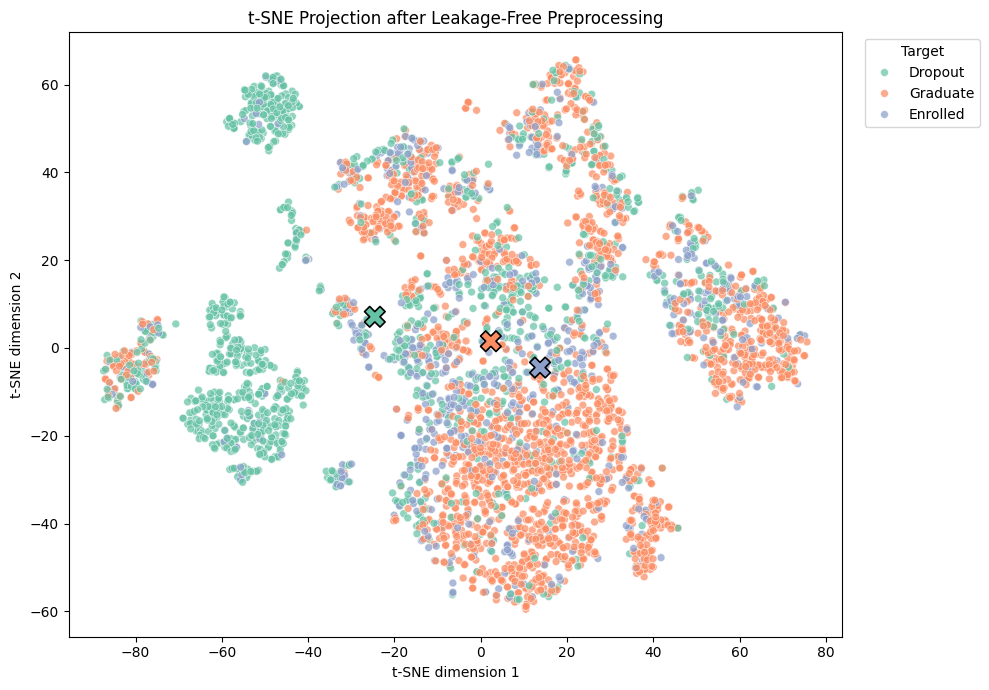


--- Centroids ---


,TSNE-1,TSNE-2
Target,,
Dropout,-24.541,7.099
Enrolled,2.340,1.536
Graduate,13.744,-4.459



--- Spread Summary ---


,mean,median,std
Target,,,
Dropout,43.084999,40.620998,16.827000
Enrolled,37.361000,37.508999,18.912001
Graduate,39.730000,40.590000,17.523001


In [55]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=tsne_df, 
    x='TSNE-1', 
    y='TSNE-2', 
    hue='Target', 
    alpha=0.72, 
    s=32, 
    palette='Set2'
)

sns.scatterplot(
    data=centroids.reset_index(), 
    x='TSNE-1', 
    y='TSNE-2', 
    hue='Target',
    marker='X', 
    s=220, 
    edgecolor='black', 
    linewidth=1.2, 
    palette='Set2', 
    legend=False
)

plt.title('t-SNE Projection after Leakage-Free Preprocessing')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.legend(title='Target', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

plt.savefig('docs/figures/tsne_projection.png', dpi=180, bbox_inches='tight')
plt.show()

print("\n--- Centroids ---")
display(centroids.round(3))
print("\n--- Spread Summary ---")
display(spread_summary.round(3))

## 3. Methods Implementation

### 3.1 Clustering

In [56]:
def perform_clustering(X, method='kmeans', n_clusters=3, **kwargs):
    method = method.lower()
    if method == 'kmeans':
        model = KMeans(n_clusters=n_clusters, **kwargs)
        labels = model.fit_predict(X)
    elif method == 'minibatchkmeans':
        model = MiniBatchKMeans(n_clusters=n_clusters, **kwargs)
        labels = model.fit_predict(X)
    elif method == 'agglomerative':
        model = AgglomerativeClustering(n_clusters=n_clusters, **kwargs)
        labels = model.fit_predict(X)
    elif method == 'gmm':
        model = GaussianMixture(n_components=n_clusters, **kwargs)
        model.fit(X)
        labels = model.predict(X)
    elif method == 'birch':
        model = Birch(n_clusters=n_clusters, **kwargs)
        labels = model.fit_predict(X)
    elif method == 'spectral':
        model = SpectralClustering(n_clusters=n_clusters, **kwargs)
        labels = model.fit_predict(X)
    elif method == 'dbscan':
        model = DBSCAN(**kwargs)
        labels = model.fit_predict(X)
    else:
        raise ValueError(f"Unexpected Method: {method}")   
    return model, labels

In [57]:
def evaluate_clustering(X, labels, y_true=None, method_name="Unknown", setting="N/A"):

    labels = np.asarray(labels)
    unique_labels = set(labels)

    noise_rate = float(np.mean(labels == -1)) if -1 in labels else 0.0
    effective_k = len(unique_labels) - (1 if -1 in unique_labels else 0)
    valid_for_internal = 2 <= effective_k < len(labels)

    if valid_for_internal:
        sil = silhouette_score(X, labels)
        ch = calinski_harabasz_score(X, labels)
        db = davies_bouldin_score(X, labels)
    else:
        sil, ch, db = np.nan, np.nan, np.nan

    result = {
        'Algorithm': method_name,
        'Setting': setting,
        'Effective_k': effective_k,
        'Noise_rate': noise_rate,
        'Silhouette': sil,
        'Calinski-Harabasz': ch,
        'Davies-Bouldin': db
    }

    if y_true is not None:
        y_codes = pd.Categorical(y_true).codes if not pd.api.types.is_numeric_dtype(y_true) else y_true
        result['ARI'] = adjusted_rand_score(y_codes, labels)
        result['NMI'] = normalized_mutual_info_score(y_codes, labels)
        result['Homogeneity'] = homogeneity_score(y_codes, labels)
        result['Completeness'] = completeness_score(y_codes, labels)
        result['V-measure'] = v_measure_score(y_codes, labels)
        
    return result

### 3.2 Prediction Models

In [58]:
def train_model(X_train, y_train, method='rf', **kwargs):
    method = method.lower()
    
    if method == 'lr':
        model = LogisticRegression(**kwargs)
    elif method == 'dt':
        model = DecisionTreeClassifier(**kwargs)
    elif method == 'rf':
        model = RandomForestClassifier(**kwargs)
    elif method == 'gbc':
        model = GradientBoostingClassifier(**kwargs)
    elif method == 'hgbc':
        model = HistGradientBoostingClassifier(**kwargs)
    elif method == 'svc':
        model = SVC(**kwargs)
    elif method == 'mlp':
        model = MLPClassifier(**kwargs)
    else:
        raise ValueError(f"Unexpected Method: {method}")
        
    model.fit(X_train, y_train)
    return model

In [59]:
def evaluate_model(model, X_test, y_test, method_name="Unknown"):
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
        try:
            if len(set(y_test)) > 2:
                roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
            else:
                roc_auc = roc_auc_score(y_test, y_prob[:, 1])
        except:
            roc_auc = None
    else:
        roc_auc = None
        
    result = {
        'Algorithm': method_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1_Macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'F1_Weighted': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'ROC_AUC': roc_auc
    }
    
    return result

### 4. Experiments

### 4.1 Clustering

Starting clustering evaluation pipeline...


--- Top Clustering Results ---


,Algorithm,Setting,Effective_k,Noise_rate,Silhouette,Calinski-Harabasz,Davies-Bouldin,ARI,NMI,Internal rank mean
0,KMeans,k=2,2,0.0,0.2530,823.9741,1.8537,0.1869,0.1990,3.6667
7,MiniBatchKMeans,k=2,2,0.0,0.2533,823.8821,1.8576,0.1880,0.1995,4.0000
1,KMeans,k=3,3,0.0,0.2499,638.9910,1.7953,0.1693,0.1762,5.0000
30,BIRCH,k=4,4,0.0,0.2508,497.2353,1.7455,0.1474,0.1593,6.6667
8,MiniBatchKMeans,k=3,3,0.0,0.2474,638.7825,1.8133,0.1710,0.1752,7.3333
36,SpectralClustering,k=3,3,0.0,0.2426,505.5786,1.5949,0.1493,0.1775,7.6667
35,SpectralClustering,k=2,2,0.0,0.2384,780.7060,1.8073,0.1643,0.1817,7.6667
28,BIRCH,k=2,2,0.0,0.2411,784.3290,1.8615,0.1782,0.1868,8.0000
14,AgglomerativeWard,k=2,2,0.0,0.2482,770.9425,2.0249,0.1963,0.1855,9.0000
17,AgglomerativeWard,k=5,5,0.0,0.2478,444.6957,1.6564,0.1627,0.1595,9.0000



--- K=3 Clustering Results ---


,Algorithm,Setting,Silhouette,Calinski-Harabasz,Davies-Bouldin,ARI,NMI,Homogeneity,Completeness,V-measure
1,KMeans,k=3,0.2499,638.9910,1.7953,0.1693,0.1762,0.1502,0.2132,0.1762
8,MiniBatchKMeans,k=3,0.2474,638.7825,1.8133,0.1710,0.1752,0.1503,0.2098,0.1752
36,SpectralClustering,k=3,0.2426,505.5786,1.5949,0.1493,0.1775,0.1395,0.2436,0.1775
29,BIRCH,k=3,0.2407,604.4174,1.8728,0.1645,0.1634,0.1404,0.1953,0.1634
15,AgglomerativeWard,k=3,0.2305,588.3753,1.9324,0.1814,0.1636,0.1426,0.1920,0.1636
22,GaussianMixture,k=3,0.1429,470.4078,3.1658,0.1786,0.1462,0.1442,0.1482,0.1462



--- DBSCAN Summary ---


,Setting,Effective_k,Noise_rate,Silhouette,ARI,NMI
40,"eps=3.0, min_samples=10",8,0.4320,-0.0810,0.1766,0.1352
41,"eps=3.0, min_samples=20",3,0.5158,0.0436,0.1558,0.1333
42,"eps=4.0, min_samples=10",2,0.0956,0.1667,0.0366,0.0534
43,"eps=4.0, min_samples=20",2,0.1227,0.1550,0.0466,0.0558
44,"eps=5.0, min_samples=10",1,0.0199,NaN,0.0047,0.0067
45,"eps=5.0, min_samples=20",1,0.0285,NaN,0.0060,0.0069
46,"eps=6.0, min_samples=10",1,0.0072,NaN,0.0016,0.0011
47,"eps=6.0, min_samples=20",1,0.0090,NaN,0.0024,0.0030
48,"eps=7.0, min_samples=10",1,0.0025,NaN,-0.0011,0.0011
49,"eps=7.0, min_samples=20",1,0.0050,NaN,0.0006,0.0007


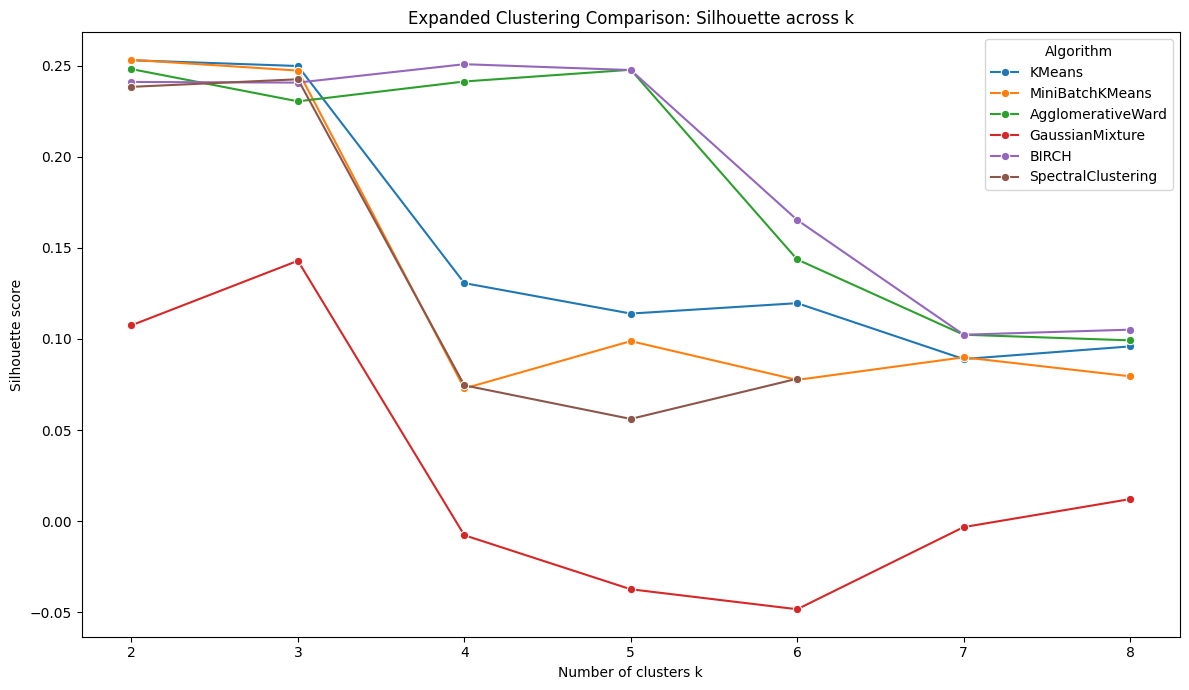

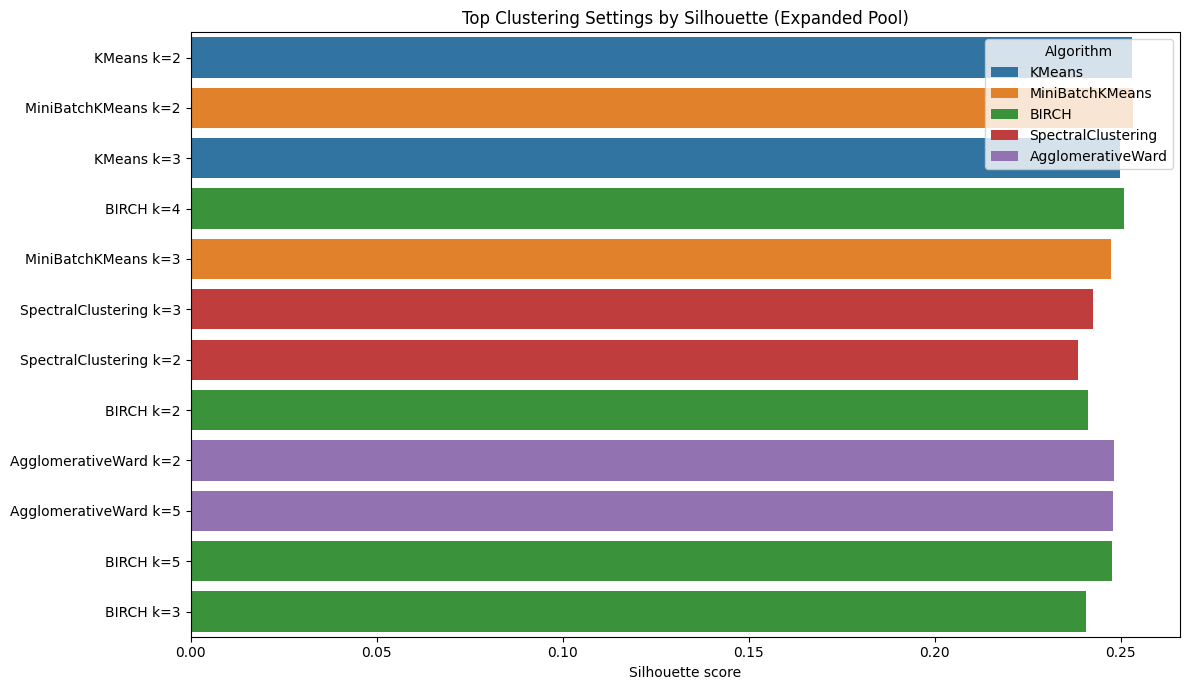

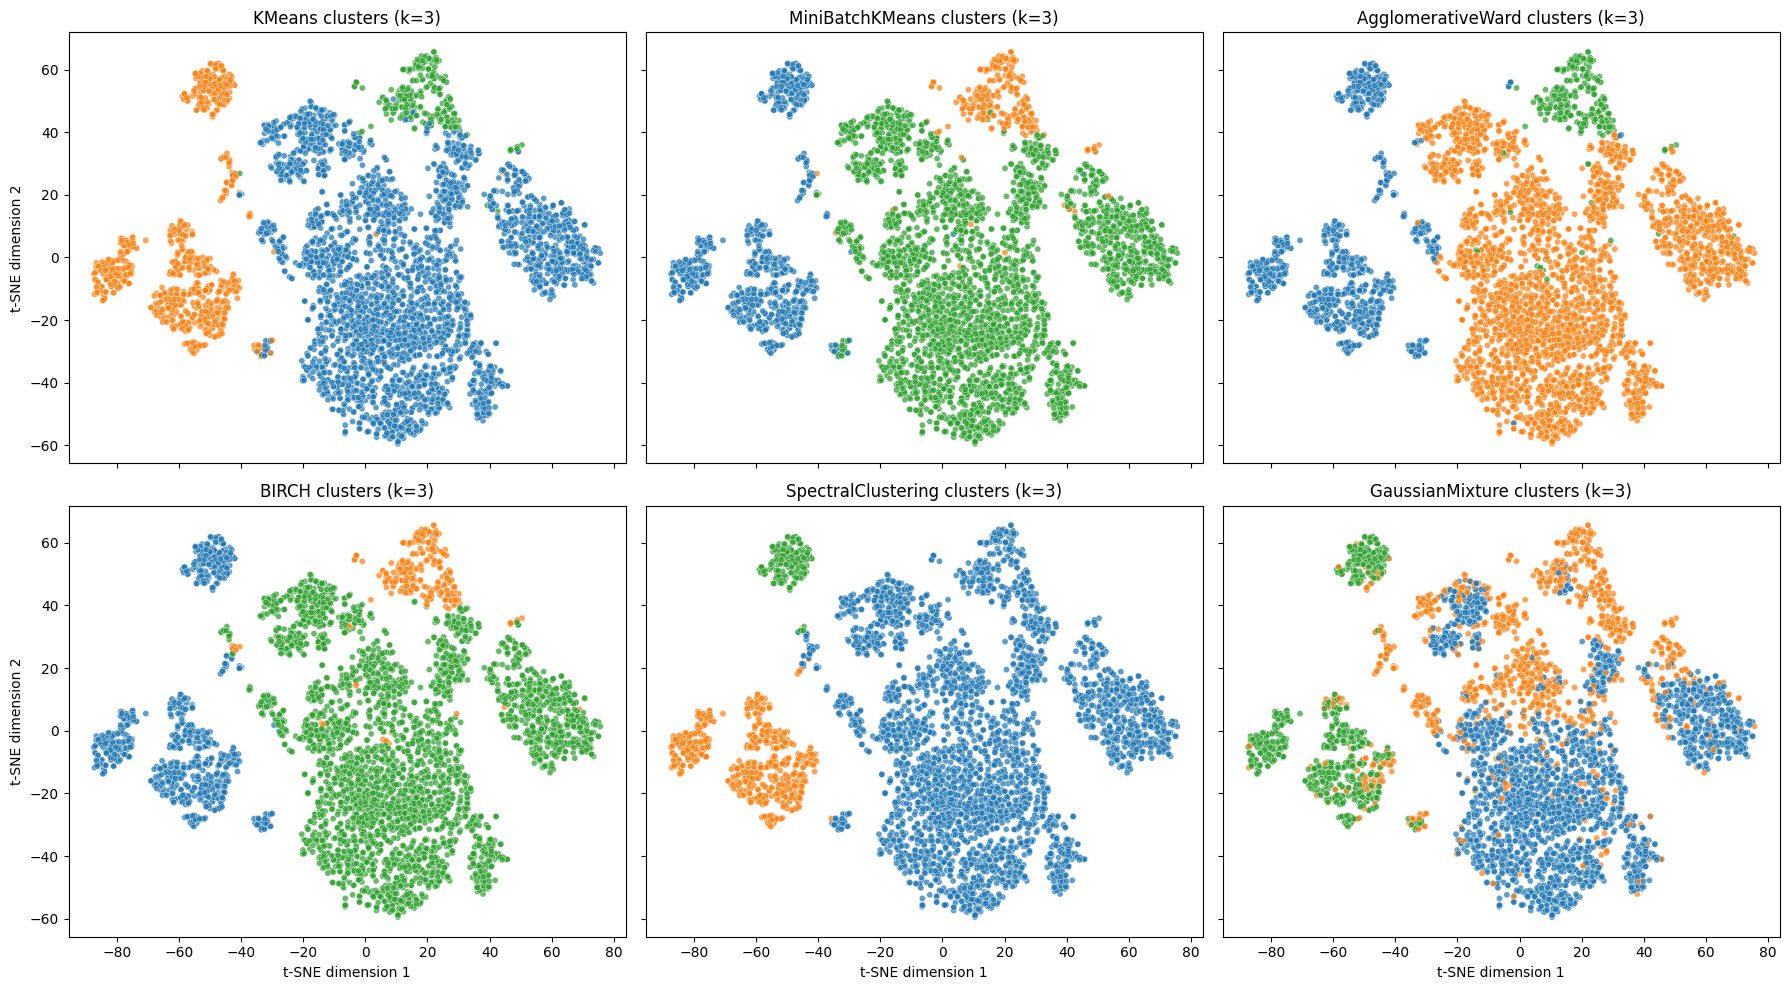

In [60]:
X_cluster = X_for_tsne  # 确保 X_for_tsne 在上下文中已定义
y_true = y              # 确保 y 在上下文中已定义
random_state = 42
results_list = []
cluster_labels = {}

print("Starting clustering evaluation pipeline...")

k_based_methods = {
    'KMeans': {'n_init': 30, 'random_state': random_state},
    'MiniBatchKMeans': {'n_init': 20, 'batch_size': 512, 'random_state': random_state},
    'AgglomerativeWard': {'linkage': 'ward'},
    'GaussianMixture': {'covariance_type': 'diag', 'n_init': 5, 'random_state': random_state},
    'BIRCH': {'threshold': 1.5},
    'SpectralClustering': {'affinity': 'nearest_neighbors', 'n_neighbors': 15, 'assign_labels': 'kmeans', 'random_state': random_state}
}

for method_name, kwargs in k_based_methods.items():
    max_k = 6 if method_name == 'SpectralClustering' else 8
    for k in range(2, max_k + 1):
        internal_method = method_name
        if method_name == 'AgglomerativeWard': internal_method = 'agglomerative'
        if method_name == 'GaussianMixture': internal_method = 'gmm'
        if method_name == 'SpectralClustering': internal_method = 'spectral'
        
        _, labels = perform_clustering(X_cluster, method=internal_method, n_clusters=k, **kwargs)
        res = evaluate_clustering(X_cluster, labels, y_true=y_true, method_name=method_name, setting=f'k={k}')
        results_list.append(res)
        cluster_labels[f'{method_name}_k={k}'] = labels

eps_values = [3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
min_samples_values = [10, 20]
for eps in eps_values:
    for min_samples in min_samples_values:
        _, labels = perform_clustering(X_cluster, method='dbscan', eps=eps, min_samples=min_samples, n_jobs=1)
        setting_str = f'eps={eps}, min_samples={min_samples}'
        res = evaluate_clustering(X_cluster, labels, y_true=y_true, method_name='DBSCAN', setting=setting_str)
        results_list.append(res)

cluster_df = pd.DataFrame(results_list)
valid_cluster_df = cluster_df.dropna(subset=['Silhouette']).copy()

valid_cluster_df['Silhouette rank'] = valid_cluster_df['Silhouette'].rank(ascending=False, method='min')
valid_cluster_df['CH rank'] = valid_cluster_df['Calinski-Harabasz'].rank(ascending=False, method='min')
valid_cluster_df['DB rank'] = valid_cluster_df['Davies-Bouldin'].rank(ascending=True, method='min')
valid_cluster_df['Internal rank mean'] = valid_cluster_df[['Silhouette rank', 'CH rank', 'DB rank']].mean(axis=1)

cluster_ranked = valid_cluster_df.sort_values(['Internal rank mean', 'Silhouette'], ascending=[True, False])
cluster_k3 = valid_cluster_df[valid_cluster_df['Setting'] == 'k=3'].sort_values('Silhouette', ascending=False)
dbscan_summary = cluster_df[cluster_df['Algorithm'] == 'DBSCAN'].copy()

best_internal = cluster_ranked.iloc[0]
best_k3 = cluster_k3.iloc[0]
best_internal_name = f"{best_internal['Algorithm']}_{best_internal['Setting']}"
best_k3_name = f"{best_k3['Algorithm']}_{best_k3['Setting']}"

print("--- Top Clustering Results ---")
display(cluster_ranked[['Algorithm', 'Setting', 'Effective_k', 'Noise_rate', 'Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin', 'ARI', 'NMI', 'Internal rank mean']].head(15).round(4))

print("\n--- K=3 Clustering Results ---")
display(cluster_k3[['Algorithm', 'Setting', 'Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin', 'ARI', 'NMI', 'Homogeneity', 'Completeness', 'V-measure']].round(4))

print("\n--- DBSCAN Summary ---")
display(dbscan_summary[['Setting', 'Effective_k', 'Noise_rate', 'Silhouette', 'ARI', 'NMI']].round(4))

line_df = valid_cluster_df[valid_cluster_df['Setting'].str.startswith('k=')].copy()
line_df['k'] = line_df['Setting'].str.extract(r'k=(\d+)').astype(int)

plt.figure(figsize=(12, 7))
sns.lineplot(data=line_df, x='k', y='Silhouette', hue='Algorithm', marker='o')
plt.title('Expanded Clustering Comparison: Silhouette across k')
plt.xlabel('Number of clusters k')
plt.ylabel('Silhouette score')
plt.tight_layout()
plt.savefig('docs/figures/clustering_expanded_silhouette_by_k.png', dpi=180, bbox_inches='tight')
plt.show()

top_cluster_plot = cluster_ranked.head(12).copy()
top_cluster_plot['Model'] = top_cluster_plot['Algorithm'] + ' ' + top_cluster_plot['Setting']
plt.figure(figsize=(12, 7))
sns.barplot(data=top_cluster_plot, y='Model', x='Silhouette', hue='Algorithm', dodge=False)
plt.title('Top Clustering Settings by Silhouette (Expanded Pool)')
plt.xlabel('Silhouette score')
plt.ylabel('')
plt.tight_layout()
plt.savefig('docs/figures/clustering_expanded_top_silhouette.png', dpi=180, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
plot_algorithms = ['KMeans', 'MiniBatchKMeans', 'AgglomerativeWard', 'BIRCH', 'SpectralClustering', 'GaussianMixture']
for ax, algorithm in zip(axes.ravel(), plot_algorithms):
    if f'{algorithm}_k=3' in cluster_labels:
        labels = cluster_labels[f'{algorithm}_k=3']
        sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels, palette='tab10', s=20, alpha=0.72, ax=ax, legend=False)
        ax.set_title(f'{algorithm} clusters (k=3)')
        ax.set_xlabel('t-SNE dimension 1')
        ax.set_ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('docs/figures/clustering_expanded_k3_on_tsne.png', dpi=180, bbox_inches='tight')
plt.show()

### 4.2 Prediction

,Algorithm,Accuracy,Precision,Recall,F1_Macro,F1_Weighted,ROC_AUC
0,RandomForest,0.7706,0.7217,0.6789,0.6896,0.7554,0.8856
1,SVC,0.7243,0.6977,0.7041,0.6893,0.7374,0.8808
2,LogisticRegression,0.7198,0.6893,0.6911,0.6807,0.7339,0.8777
3,HistGradientBoosting,0.7480,0.6858,0.6697,0.6754,0.7405,0.8818
4,GradientBoosting,0.7514,0.6876,0.6679,0.6742,0.7416,0.8868
5,MLP,0.7119,0.6428,0.6425,0.6426,0.7106,0.8319
6,DecisionTree,0.6689,0.6025,0.6032,0.6027,0.6712,0.7168


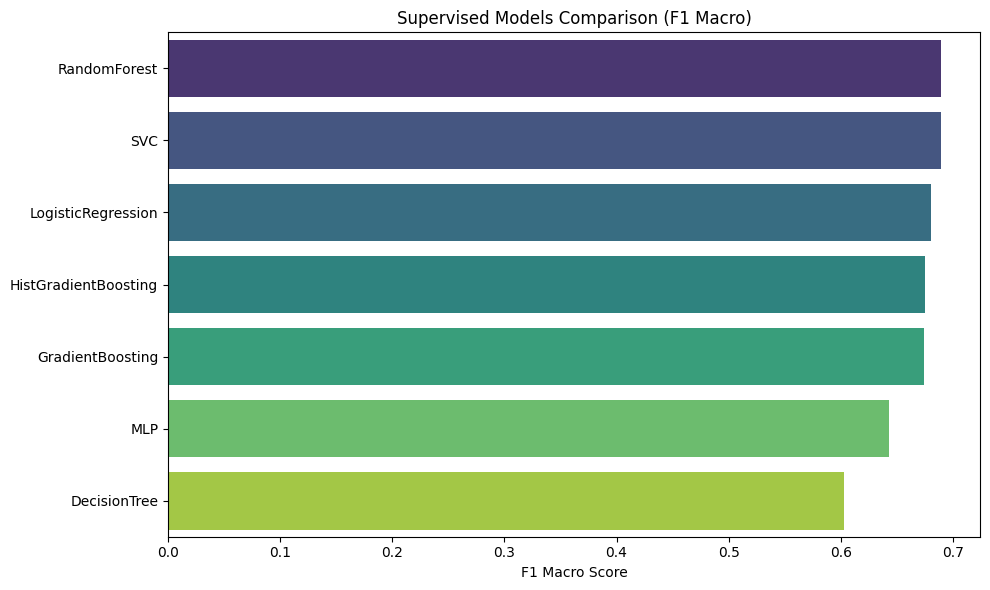

In [62]:

X_train, X_test, y_train, y_test = train_test_split(X_dense, y, test_size=0.2, random_state=42, stratify=y)

prediction_results = []
trained_models = {}

models_to_run = {
    'LogisticRegression': ('lr', {'max_iter': 2000, 'class_weight': 'balanced', 'random_state': 42}),
    'DecisionTree': ('dt', {'class_weight': 'balanced', 'random_state': 42}),
    'RandomForest': ('rf', {'n_estimators': 200, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}),
    'GradientBoosting': ('gbc', {'random_state': 42}),
    'HistGradientBoosting': ('hgbc', {'random_state': 42}),
    'SVC': ('svc', {'probability': True, 'class_weight': 'balanced', 'random_state': 42}),
    'MLP': ('mlp', {'max_iter': 1000, 'random_state': 42})
}

for name, (method_code, kwargs) in models_to_run.items():
    model = train_model(X_train, y_train, method=method_code, **kwargs)
    trained_models[name] = model
    
    res = evaluate_model(model, X_test, y_test, method_name=name)
    prediction_results.append(res)

results_df = pd.DataFrame(prediction_results).sort_values(by='F1_Macro', ascending=False).reset_index(drop=True)
display(results_df.round(4))


plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='F1_Macro', y='Algorithm', hue='Algorithm', legend=False, palette='viridis')
plt.title('Supervised Models Comparison (F1 Macro)')
plt.xlabel('F1 Macro Score')
plt.ylabel('')
plt.tight_layout()
plt.savefig('docs/figures/prediction_f1_macro_comparison.png', dpi=180, bbox_inches='tight')
plt.show()